# Reverse Process Test

In [1]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from pathlib import Path


# additional elements for conditional
from torchvision import transforms
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader, random_split

# Ottieni il percorso della cartella CORRENTE
current_dir = os.getcwd()

# Ottieni il percorso della cartella GENITORE (quella sopra)
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Aggiungi la cartella genitore al path
sys.path.append(parent_dir)
from src.utils.utils import log_denoising_step_wandb


# Parameters to set

In [2]:
# Set the following parameters
sde_type = "subVP"
num_steps = 1000
batch_size = 10
VAE_SCALE_FACTOR = 0.18215
guidance_scale = 1.5
num_attributes = 40
conditional = True
cfg_mask_prob = 0.1


cfg = {
    "sde_type": sde_type,
    "N": num_steps, 
    "vae_scale_factor" : VAE_SCALE_FACTOR,
    "guidance_scale": guidance_scale,
    "num_attributes": num_attributes,
    "conditional": conditional,
    "cfg_mask_prob": cfg_mask_prob,
    "image_size": 256,
    "validation_split_ratio": 0.2,
    "num_workers": 0,
    "seed": 42,
    "batch_size": batch_size
}

In [3]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [4]:
weights_name = 'LDM_final_T1000_LR00001_E100_SA_CFG_RESUME_CFG_ts20260113_104450.pth' 

In [5]:
from src.utils import WIP_SDE, WIP_processes
from src.models import components
from src.models import UNet


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(UNet)

# UNet = unet_model.UNet
# Unet = unet_base.Unet
UNet = UNet.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet


In [6]:
diffusion = Diffusion_Processes(cfg)
diffusion.sde_type

'subvp'

In [7]:
# from diffusers import UNet2DModel
# model_id = "google/ncsnpp-celebahq-256"
# model = UNet2DModel.from_pretrained(model_id)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")
# model.to(device)
# model.eval()


# Weights to test (Our Model)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the REAL Unet model from unet_model.py
print("Instantiating UNet model...")
model = UNet(in_channels=4, out_channels=4).to(device)
model

Using device: cuda
Instantiating UNet model...


UNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (attribute_encoder): Sequential(
    (0): Linear(in_features=40, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_conv): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Sequential(
        (0): SiLU()
        (1): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU()
      (dropout): Dropout(p=0.0, inplace=False)
      (

In [9]:
def _extract_state_dict(ckpt):
    for k in ("state_dict", "model",  "model_state_dict"): #, "ema"):
        if isinstance(ckpt, dict) and k in ckpt and isinstance(ckpt[k], dict):
            return ckpt[k]
    return ckpt

def _remove_ema(sd: dict) -> dict:
    return {
        k: v for k, v in sd.items()
        if not (
            k.startswith("ema.") or
            k.startswith("ema_model.") or
            k.startswith("model_ema.")
        )
    }


def _strip_prefixes(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        sd = {k.split("module.", 1)[1] if k.startswith("module.") else k: v for k, v in sd.items()}
    # if all(k.startswith("unet.") for k in sd):
    sd = {k.replace("unet.", "", 1) if k.startswith("unet.") else k: v for k, v in sd.items()}
    return sd

def load_model_from_local(model: nn.Module, ckpt_path: str, device: torch.device) -> bool:
    """Load checkpoint from local filesystem instead of Google Drive."""
    if not os.path.isfile(ckpt_path):
        print(f"Error: Checkpoint not found at {ckpt_path}")
        return False
    print(f"Loading model weights from {ckpt_path} ...")

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    except Exception as e:
        print(f"[torch.load] failed: {e}")
        return False

    sd = _extract_state_dict(ckpt)
    sd = _strip_prefixes(sd)
    sd = _remove_ema(sd)



    num_tensors = len(sd)
    num_params = sum(v.numel() for v in sd.values() if torch.is_tensor(v))
    print(f"Checkpoint state_dict: {num_tensors} tensors, {num_params:,} total parameters")

    model_keys = set(model.state_dict().keys())
    filtered = {k: v for k, v in sd.items() if k in model_keys}

    dropped = sorted(k for k in sd.keys() if k not in model_keys)
    if dropped:
        print(f"Dropping {len(dropped)} unexpected keys (showing up to 8):")
        for k in dropped[:]:
            print("  ", k)
        if len(dropped) > 8:
            print("  ...")

    res = model.load_state_dict(filtered, strict=False)
    print(f"Loaded. missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}")

    model.to(device).eval()
    return True

In [10]:
# --- 3. Load Weights ---
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
ckpt_path = weights_dir.joinpath(weights_name)
load_model_from_local(model, ckpt_path, device)
ckpt_path

Model parameters: 12,874,308
Loading model weights from c:\Users\marco\Desktop\Magistrale\ERASMUS\COURSES TUM\Practicals\Hands on Generative AI\Project\Hands-on-Generative-AI\checkpoints\weights\LDM_final_T1000_LR00001_E100_SA_CFG_RESUME_CFG_ts20260113_104450.pth ...
Checkpoint state_dict: 267 tensors, 12,874,308 total parameters
Loaded. missing=0 unexpected=0


WindowsPath('c:/Users/marco/Desktop/Magistrale/ERASMUS/COURSES TUM/Practicals/Hands on Generative AI/Project/Hands-on-Generative-AI/checkpoints/weights/LDM_final_T1000_LR00001_E100_SA_CFG_RESUME_CFG_ts20260113_104450.pth')

In [11]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t, labels):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t, labels)
            
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out


In [12]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(next(model.parameters()).device).eval()
VAE_SCALE_FACTOR = cfg['vae_scale_factor']
VAE_SCALE_FACTOR

0.18215

In [13]:
def decode_from_latent(latents: torch.Tensor):
    """Converte latenti in pixel [0, 1]."""
    latents = latents / VAE_SCALE_FACTOR
    with torch.no_grad():
        image = vae.decode(latents).sample
    return (image / 2 + 0.5).clamp(0, 1)

# Loading the dataset
We need to load the dataset in order to get the labels

In [ ]:
image_size = cfg['image_size']
transform = transforms.Compose([transforms.CenterCrop(178), transforms.Resize((image_size, image_size)), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
full_dataset = CelebA(
            root="../data",
            # root = data_path
            split="train",
            target_type="attr",
            transform=transform,
            download=False   
        )

# indices = np.arange(128)  # Example indices for a small subset
# full_dataset = torch.utils.data.Subset(full_dataset, indices)
# Define split sizes
val_size = int(cfg['validation_split_ratio'] * len(full_dataset))
train_size = len(full_dataset) - val_size

# Deterministic Split for reproducibility
torch.manual_seed(cfg['seed'])
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)
# train_dataset = full_dataset
# val_dataset = full_dataset
# Create DataLoaders


train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'], shuffle=True, num_workers=cfg['num_workers'])# CHange Batch size

In [ ]:
first_image, first_label = full_dataset[0]


print(f"Label shape originale: {first_label}")

Label shape originale: tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1])


----- Reverse Process -----
This is our batch size: 1
This is our SDE: <src.utils.WIP_SDE.SubVPSDE object at 0x00000285AC163D50>
This is the value of T: 1.0
Check prior subvp: Mean = 0.037094008177518845, Std = 0.9973270297050476
[reverse step 901/1000 | i=900 | t=0.9000]
mean=0.0291, std=1.0003, min=-3.6850, max=3.7180
Time of last 100 steps: 6.3993752002716064. Time remaining 63.993752002716064.



[reverse step 901/1000 | i=900 | t=0.9000]
mean=0.0291, std=1.0003, min=-3.6850, max=3.7180
Time of last 100 steps: 5.605731248855591. Time remaining 56.05731248855591.



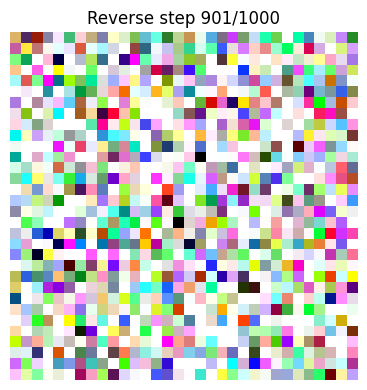

[reverse step 801/1000 | i=800 | t=0.8000]
mean=0.0342, std=0.9939, min=-3.4261, max=3.9339
Time of last 100 steps: 6.374193906784058. Time remaining 127.48387813568115.



In [ ]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
import wandb
batch_size = 1
labels_men = [0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]
test_labels = first_label.to(device)
test_labels = torch.tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1], dtype=torch.float32).to(device)

#test_labels = torch.tensor(labels_men, device=device)

callback_fn = log_denoising_step_wandb

wandb.init(project="LDM_Testing", name=f"Sampling_WO_Scores_{weights_name}")

samples = diffusion.reverse_process(
    model=model_fn,             
    shape=(batch_size, 4, 32, 32),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device,
    labels = test_labels,              # Pass device explicitly
    caption="debug", 
    callback_fn=callback_fn
)
wandb.finish()

Grid salvata in: images/decoded_grid_steps_1000_LDM_final_T1000_LR00001_E100_SA_CFG_RESUME_CFG_ts20260112_232155.pth.png


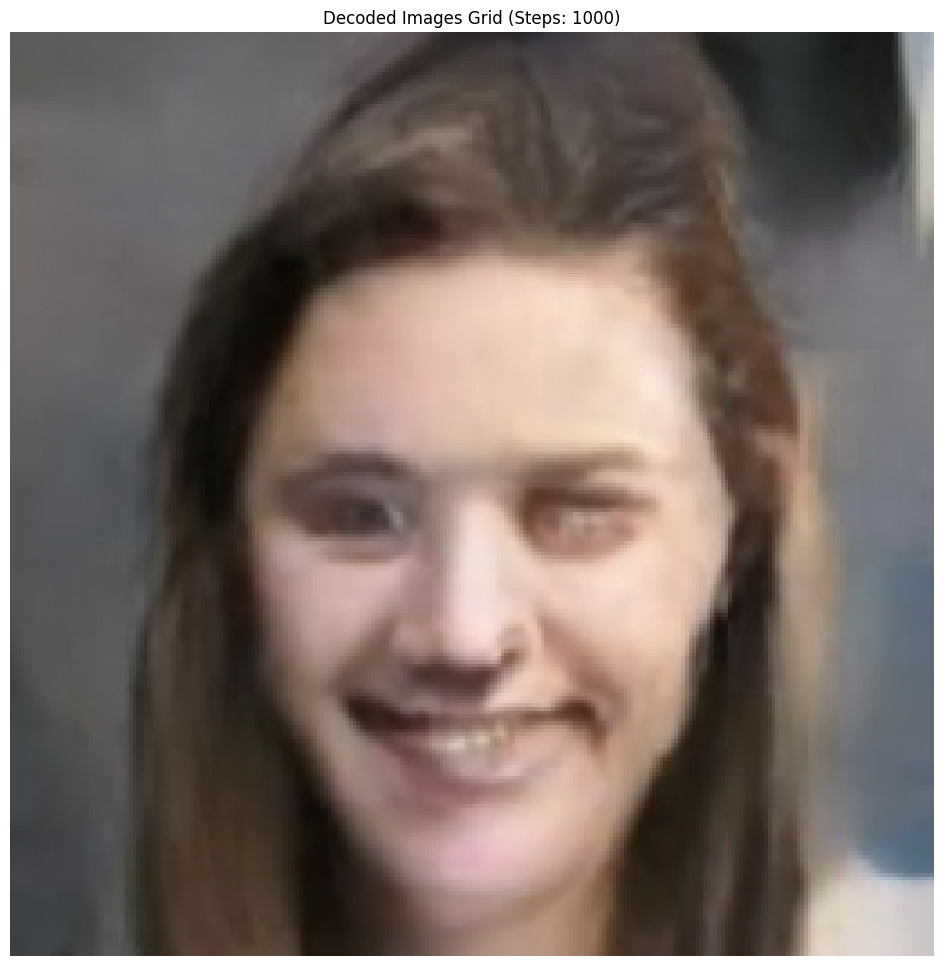

In [ ]:
decoded_images = []

# --- 1. Decodifica tutte le immagini e salva in una lista ---
for latent in samples:
    latent = latent.to(next(vae.parameters()).device, dtype=torch.float32).unsqueeze(0)
    decoded = decode_from_latent(latent)  # [1, C, H, W]
    decoded_images.append(decoded[0])      # Rimuovi dimensione batch

# --- 2. Crea un batch da lista di tensori ---
decoded_batch = torch.stack(decoded_images)  # [B, C, H, W]
# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(decoded_batch, nrow=4, normalize=True, value_range=(0, 1))


# Salva la griglia
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")

# 🔹 Salvataggio
save_path = f"images/decoded_grid_steps_{cfg['N']}_{weights_name}_CFG_{diffusion.guidance_scale}.png"
plt.savefig(save_path, bbox_inches="tight", dpi=300)

print(f"Grid salvata in: {save_path}")
